In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
data_path = "/mnt/c/Users/tanbi/Downloads/d04_text_station_5min_2026_01_01/d04_text_station_5min_2026_01_01.txt"
print(os.path.exists(data_path))
data_df = pd.read_csv(data_path, header=None)

True


In [3]:
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1110240 entries, 0 to 1110239
Data columns (total 52 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   0       1110240 non-null  str    
 1   1       1110240 non-null  int64  
 2   2       1110240 non-null  int64  
 3   3       1110240 non-null  int64  
 4   4       1110240 non-null  str    
 5   5       1110240 non-null  str    
 6   6       651456 non-null   float64
 7   7       1110240 non-null  int64  
 8   8       1110240 non-null  int64  
 9   9       900379 non-null   float64
 10  10      900379 non-null   float64
 11  11      650880 non-null   float64
 12  12      1110240 non-null  int64  
 13  13      884665 non-null   float64
 14  14      884665 non-null   float64
 15  15      650880 non-null   float64
 16  16      1110240 non-null  int64  
 17  17      850176 non-null   float64
 18  18      773643 non-null   float64
 19  19      773643 non-null   float64
 20  20      643680 non-null   float64
 

## From column 12 to 51, this pattern repeats and the columns are:
### Lane 1 : samples ; 
### Lane 1 : flow ; 
### Lane 1 : Avg Ocucpancy ; 
### Lane 1 : Avg Speed ; 
### Lane 1 : Observed
### Lane 2 : samples ; 
### Lane 2 : flow ; 
### Lane 2 : Avg Ocucpancy ; 
### Lane 2 : Avg Speed ; 
### Lane 2 : Observed
### ...
### Lane 8 : samples ; 
### Lane 8 : flow ; 
### Lane 8 : Avg Ocucpancy ; 
### Lane 8 : Avg Speed ; 
### Lane 8 : Observed

In [4]:
columns_12 = ["timestamp", "station", "district", "freeway", "direction", "lane_type", 
           "station_length", "samples", "perc_obs", "total_flow", "avg_occupancy", 
           "avg_speed"]
rest_columns = [
    col
    for i in range(1, 9)
    for col in [
        f"lane_{i}_samples", 
        f"lane_{i}_flow", 
        f"lane_{i}_avg_occp", 
        f"lane_{i}_avg_speed", 
        f"lane_{i}_observed"        
    ]
]
data_df.columns = columns_12 + rest_columns
print(data_df.columns)

Index(['timestamp', 'station', 'district', 'freeway', 'direction', 'lane_type',
       'station_length', 'samples', 'perc_obs', 'total_flow', 'avg_occupancy',
       'avg_speed', 'lane_1_samples', 'lane_1_flow', 'lane_1_avg_occp',
       'lane_1_avg_speed', 'lane_1_observed', 'lane_2_samples', 'lane_2_flow',
       'lane_2_avg_occp', 'lane_2_avg_speed', 'lane_2_observed',
       'lane_3_samples', 'lane_3_flow', 'lane_3_avg_occp', 'lane_3_avg_speed',
       'lane_3_observed', 'lane_4_samples', 'lane_4_flow', 'lane_4_avg_occp',
       'lane_4_avg_speed', 'lane_4_observed', 'lane_5_samples', 'lane_5_flow',
       'lane_5_avg_occp', 'lane_5_avg_speed', 'lane_5_observed',
       'lane_6_samples', 'lane_6_flow', 'lane_6_avg_occp', 'lane_6_avg_speed',
       'lane_6_observed', 'lane_7_samples', 'lane_7_flow', 'lane_7_avg_occp',
       'lane_7_avg_speed', 'lane_7_observed', 'lane_8_samples', 'lane_8_flow',
       'lane_8_avg_occp', 'lane_8_avg_speed', 'lane_8_observed'],
      dtype='str')


In [5]:
data_df.head()

,timestamp,station,district,freeway,direction,lane_type,station_length,samples,perc_obs,total_flow,...,lane_7_samples,lane_7_flow,lane_7_avg_occp,lane_7_avg_speed,lane_7_observed,lane_8_samples,lane_8_flow,lane_8_avg_occp,lane_8_avg_speed,lane_8_observed
0,01/01/2026 00:00:00,400000,4,101,S,ML,0.415,40,100,39.0,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0
1,01/01/2026 00:00:00,400001,4,101,N,ML,0.265,50,0,85.0,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0
2,01/01/2026 00:00:00,400002,4,101,S,ML,0.305,50,0,179.0,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0
3,01/01/2026 00:00:00,400006,4,880,S,ML,0.340,40,100,92.0,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0
4,01/01/2026 00:00:00,400007,4,101,N,ML,0.365,50,0,146.0,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0


In [25]:
station_metadata_df = data_df[["station", "district", "freeway", "direction", "lane_type", "station_length"]].drop_duplicates(subset="station")
station_metadata_df = station_metadata_df.set_index("station")

In [36]:
station_metadata_df[station_metadata_df["freeway"]==85]

,district,freeway,direction,lane_type,station_length
station,,,,,
400017,4,85,S,ML,0.430
400052,4,85,N,ML,0.500
400059,4,85,S,ML,1.005
400085,4,85,S,ML,0.565
400097,4,85,S,ML,1.075
...,...,...,...,...,...
428027,4,85,S,OR,NaN
428028,4,85,S,OR,NaN
428029,4,85,S,OR,NaN


In [6]:
# types on lanes
data_df["lane_type"].value_counts()

lane_type
ML    650304
OR    263232
FR    180000
FF     16128
HV       576
Name: count, dtype: int64

### We have 5 Lanes type here.

In [7]:
data_df["timestamp"].value_counts()

timestamp
01/01/2026 00:00:00    3855
01/01/2026 00:05:00    3855
01/01/2026 00:10:00    3855
01/01/2026 00:15:00    3855
01/01/2026 00:20:00    3855
                       ... 
01/01/2026 23:35:00    3855
01/01/2026 23:40:00    3855
01/01/2026 23:45:00    3855
01/01/2026 23:50:00    3855
01/01/2026 23:55:00    3855
Name: count, Length: 288, dtype: int64

### For each 5 minutes -> we have 3855 data samples, from 3855 unique stations

In [8]:
def count_lanes(row):
    lanes=0
    for i in range(1, 9):
        if pd.notna(row[f"lane_{i}_samples"]):
            lanes+=1
    return lanes
data_mainline["num_lanes"] = data_mainline.apply(count_lanes, axis=1)

NameError: name 'data_mainline' is not defined

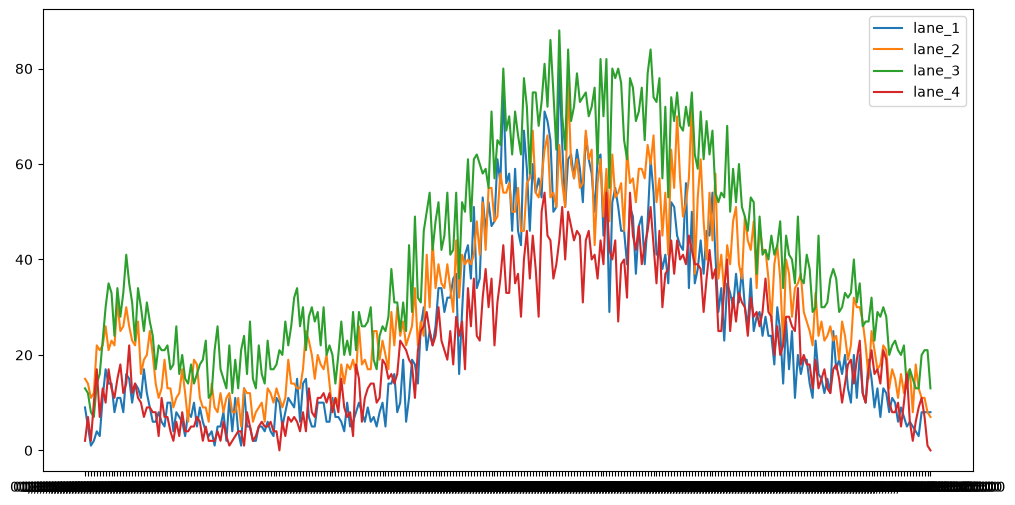

In [43]:
group_lanes = data_mainline[data_mainline["freeway"] == 101].groupby("num_lanes")
lane_4 = group_lanes.get_group(4)
station_id = lane_4["station"].iloc[0]
station_data = lane_4[lane_4["station"] == station_id]
station_data = station_data.sort_values("timestamp")
plt.figure(figsize=(12, 6))
for i in range(1, 5):
    plt.plot(
        station_data["timestamp"],
        station_data[f"lane_{i}_flow"],
        label=f"lane_{i}"
    )
plt.legend()
plt.show()

In [9]:
flow_matrix = data_df.pivot(index='timestamp', columns='station', values='total_flow')
flow_matrix

station,400000,400001,400002,400006,400007,400009,400010,400011,400014,400017,...,431020,431021,431024,431051,431058,431078,431080,431101,431104,431705
timestamp,,,,,,,,,,,,,,,,,,,,,
01/01/2026 00:00:00,39.0,85.0,179.0,92.0,146.0,116.0,98.0,128.0,58.0,62.0,...,NaN,82.0,95.0,NaN,64.0,64.0,NaN,58.0,43.0,117.0
01/01/2026 00:05:00,38.0,66.0,167.0,97.0,158.0,126.0,88.0,150.0,41.0,54.0,...,NaN,82.0,90.0,NaN,60.0,60.0,NaN,64.0,43.0,120.0
01/01/2026 00:10:00,22.0,85.0,150.0,81.0,91.0,135.0,76.0,135.0,43.0,58.0,...,NaN,80.0,88.0,NaN,59.0,59.0,NaN,68.0,45.0,115.0
01/01/2026 00:15:00,31.0,92.0,147.0,105.0,147.0,174.0,57.0,112.0,44.0,101.0,...,NaN,73.0,84.0,NaN,57.0,57.0,NaN,75.0,53.0,113.0
01/01/2026 00:20:00,57.0,166.0,194.0,124.0,147.0,169.0,75.0,158.0,74.0,90.0,...,NaN,67.0,79.0,NaN,52.0,52.0,NaN,64.0,51.0,157.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
01/01/2026 23:35:00,38.0,132.0,191.0,140.0,163.0,153.0,89.0,141.0,67.0,64.0,...,NaN,94.0,132.0,NaN,88.0,88.0,NaN,64.0,45.0,136.0
01/01/2026 23:40:00,50.0,119.0,227.0,122.0,162.0,146.0,91.0,138.0,62.0,69.0,...,NaN,86.0,132.0,NaN,88.0,88.0,NaN,57.0,64.0,122.0
01/01/2026 23:45:00,47.0,154.0,213.0,114.0,187.0,126.0,77.0,152.0,59.0,73.0,...,NaN,78.0,125.0,NaN,84.0,84.0,NaN,58.0,62.0,173.0


In [10]:
data_df["station"].nunique()

3855

In [11]:
nan_counts = flow_matrix.isna().sum()
print(nan_counts[nan_counts > 86].count()) # more then 30% Nan values, then drop those stations
print(flow_matrix.columns)

729
Index([400000, 400001, 400002, 400006, 400007, 400009, 400010, 400011, 400014,
       400017,
       ...
       431020, 431021, 431024, 431051, 431058, 431078, 431080, 431101, 431104,
       431705],
      dtype='int64', name='station', length=3855)


3855